<a href="https://colab.research.google.com/github/florence-aikins/skin-lesion-classification/blob/main/skin_lession_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"florenceaikins","key":"2b8c6e6befc8d6025c884b9bfcc5baa7"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [04:13<00:00, 22.0MB/s]



In [ ]:
!unzip skin-cancer-mnist-ham10000.zip

Streaming output truncated to the last 5000 lines.
  inflating: ham10000_images_part_2/ISIC_0029325.jpg  
  inflating: ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: ham10000_images_part_2/ISIC_0029338.jpg  
  inflating: ham10000_images_part_2/ISIC_0029339.jpg  
  inflating: ham10000_images_part_2/ISIC_0029340.jpg  
  inflating: ham10000_images_part_2/ISIC_0029341.jpg  
  inflating: h

In [ ]:
!ls

ham10000_images_part_1	HAM10000_metadata.csv  hmnist_8_8_RGB.csv
HAM10000_images_part_1	hmnist_28_28_L.csv     kaggle.json
ham10000_images_part_2	hmnist_28_28_RGB.csv   sample_data
HAM10000_images_part_2	hmnist_8_8_L.csv       skin-cancer-mnist-ham10000.zip


In [ ]:
import os
os.listdir()

['.config',
 'ham10000_images_part_1',
 'HAM10000_metadata.csv',
 'ham10000_images_part_2',
 'hmnist_28_28_L.csv',
 'HAM10000_images_part_2',
 'hmnist_28_28_RGB.csv',
 'HAM10000_images_part_1',
 'skin-cancer-mnist-ham10000.zip',
 'kaggle.json',
 'hmnist_8_8_L.csv',
 'hmnist_8_8_RGB.csv',
 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('HAM10000_metadata.csv')

EDA

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.shape

(10015, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


In [ ]:
df["dx"].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [ ]:
df["dx_type"].value_counts()

,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


In [ ]:
df["age"].value_counts()

,count
age,
45.0,1299
50.0,1187
55.0,1009
40.0,985
60.0,803
70.0,756
35.0,753
65.0,731
75.0,618


In [ ]:
df["sex"].value_counts()

,count
sex,
male,5406
female,4552
unknown,57


In [ ]:
df["localization"].value_counts()

,count
localization,
back,2192
lower extremity,2077
trunk,1404
upper extremity,1118
abdomen,1022
face,745
chest,407
foot,319
unknown,234


In [ ]:
malignant = ['akiec', 'bcc', 'mel']
benign = ['nv', 'vasc', 'bkl', 'df']

In [ ]:
df['target']=df['dx'].apply(lambda x: 1 if x in malignant else 0)

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


In [ ]:
df["target"].value_counts()

,count
target,
0,8061
1,1954


In [ ]:
df.tail()

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,1
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,1
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,1
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,1
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back,1


In [ ]:
df.sample(10)

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
5588,HAM_0004451,ISIC_0027992,nv,follow_up,55.0,female,trunk,0
5897,HAM_0004944,ISIC_0030559,nv,follow_up,75.0,male,trunk,0
241,HAM_0007341,ISIC_0032898,bkl,histo,50.0,female,lower extremity,0
5442,HAM_0005595,ISIC_0029180,nv,follow_up,70.0,male,trunk,0
669,HAM_0004338,ISIC_0026523,bkl,histo,65.0,female,face,0
9994,HAM_0000193,ISIC_0030877,akiec,histo,60.0,female,face,1
2730,HAM_0006575,ISIC_0029391,bcc,histo,65.0,female,chest,1
7889,HAM_0005594,ISIC_0033703,nv,histo,40.0,female,neck,0
8716,HAM_0001552,ISIC_0030981,nv,histo,15.0,male,face,0
788,HAM_0002042,ISIC_0028662,bkl,confocal,75.0,female,face,0


In [ ]:
df['sex'] = df['sex'].map({'female':0, 'male':1})

In [ ]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [ ]:
df['sex'] = df['sex'].astype(int)

In [ ]:
df['sex'].isnull().sum()

np.int64(0)

In [ ]:
df['sex'].sample(5)

,sex
5782,1
6806,0
8561,0
7831,0
9788,1


In [ ]:
df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
8404,HAM_0000143,ISIC_0027751,nv,histo,15.0,0,trunk,0
6482,HAM_0006008,ISIC_0028342,nv,follow_up,35.0,0,lower extremity,0
6701,HAM_0007255,ISIC_0026519,nv,histo,40.0,1,lower extremity,0
5328,HAM_0003712,ISIC_0024513,nv,follow_up,75.0,1,upper extremity,0
1189,HAM_0005529,ISIC_0025980,df,consensus,55.0,0,lower extremity,0


In [ ]:
df['age'] = df['age'].fillna(df['age'].mean())

In [ ]:
df['age'] = df['age'].astype(int)

In [ ]:
df.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
6242,HAM_0005380,ISIC_0027464,nv,follow_up,40,0,lower extremity,0
9567,HAM_0004190,ISIC_0033039,nv,consensus,40,0,unknown,0
5076,HAM_0003170,ISIC_0029631,nv,follow_up,50,1,trunk,0
2095,HAM_0002609,ISIC_0029318,mel,histo,60,0,back,1
513,HAM_0007018,ISIC_0027006,bkl,histo,75,1,chest,0


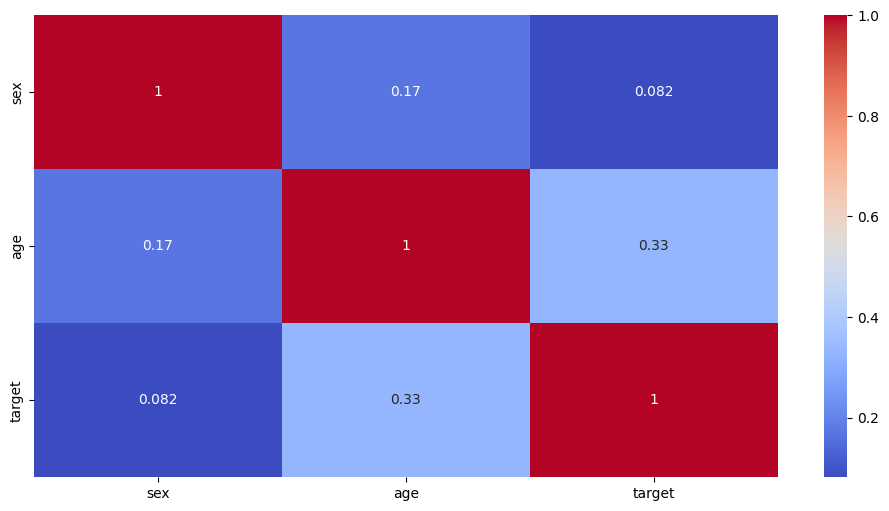

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['sex', 'age', 'target']].corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

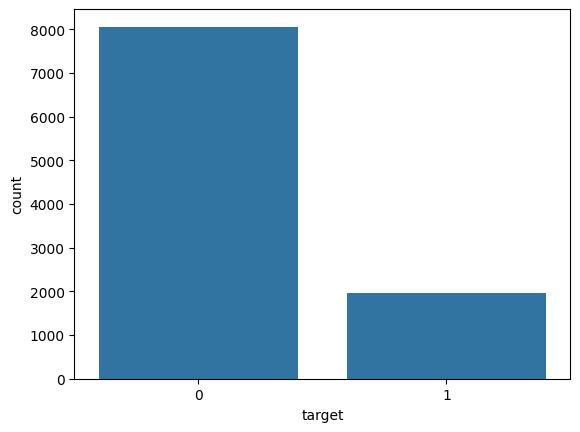

In [ ]:
sns.countplot(x='target', data=df)
plt.show()

In [ ]:
#binary dataset is imbalanced

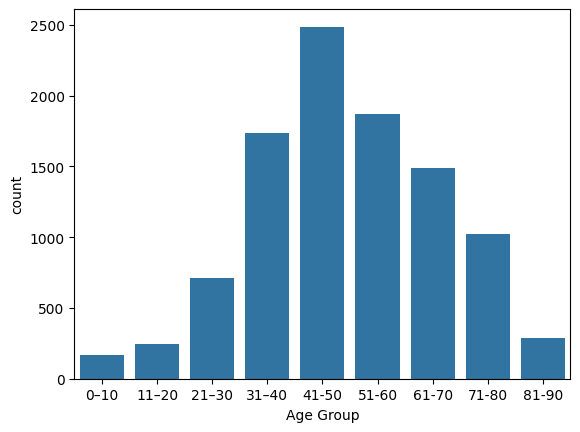

In [ ]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ['0–10', '11–20', '21–30', '31–40', '41-50', '51-60', '61-70', '71-80', '81-90']

df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

sns.countplot(x='Age Group', data=df)
plt.show()

In [ ]:
# The highest concentration of patients is between 41 and 50 years, with the peak occurring around 45 years.
# The distribution is slightly right-skewed

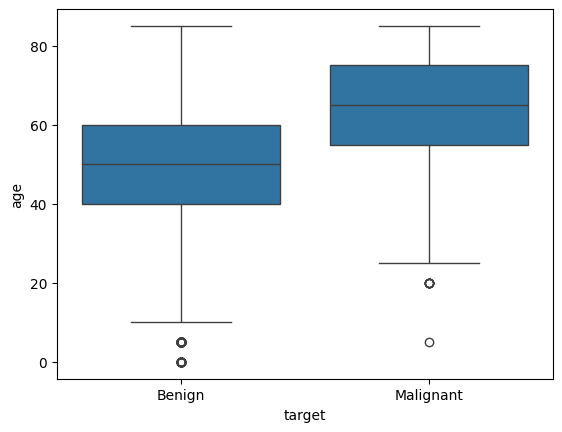

In [ ]:
sns.boxplot(x='target', y='age', data=df)
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.show()

In [ ]:
#malignant lesions are more in older people than younger people

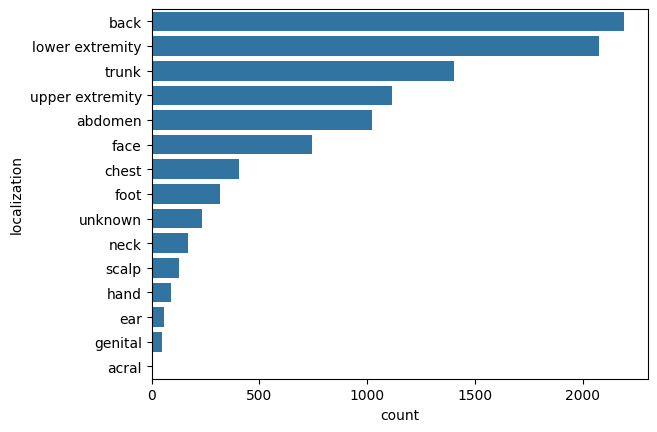

In [ ]:
sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index)
plt.show()

In [ ]:
# the back is the most common body part
# acral is the least common

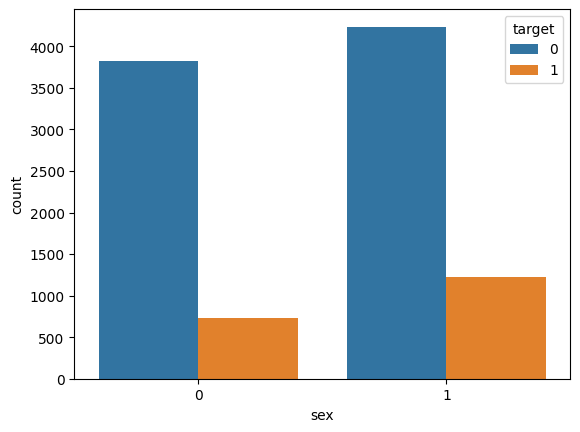

In [ ]:
sns.countplot(x='sex', hue='target', data=df)
plt.show()

In [ ]:
#there are more malignant lesions in males than females

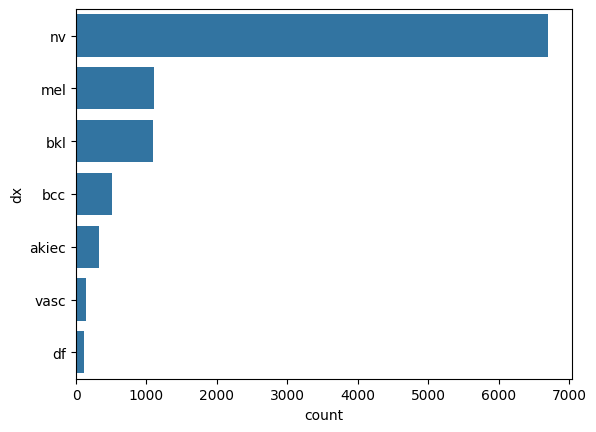

In [ ]:
sns.countplot(y='dx', data=df, order=df['dx'].value_counts().index)
plt.show()

In [ ]:
#nv is the largest class, indicating class imbalance.

([0, 1, 2, 3],
 [Text(0, 0, 'histo'),
  Text(1, 0, 'consensus'),
  Text(2, 0, 'confocal'),
  Text(3, 0, 'follow_up')])

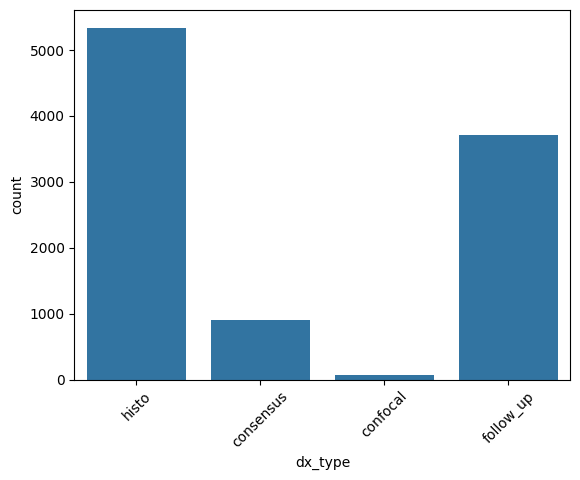

In [ ]:
sns.countplot(x='dx_type', data=df)
plt.xticks(rotation=45)

In [ ]:
#most diagnosis was confirmed through histopathology and follow-ups

In [ ]:
from glob import glob

image_paths = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob('/content/HAM10000_images_part_*/*.jpg')
}

df['path'] = df['image_id'].map(image_paths.get)

In [ ]:
from PIL import Image

sizes = df['path'].apply(lambda x: Image.open(x).size)
sizes.value_counts()

,count
path,
"(600, 450)",10015


In [ ]:
#all images have the same dimensons. no need for resizing

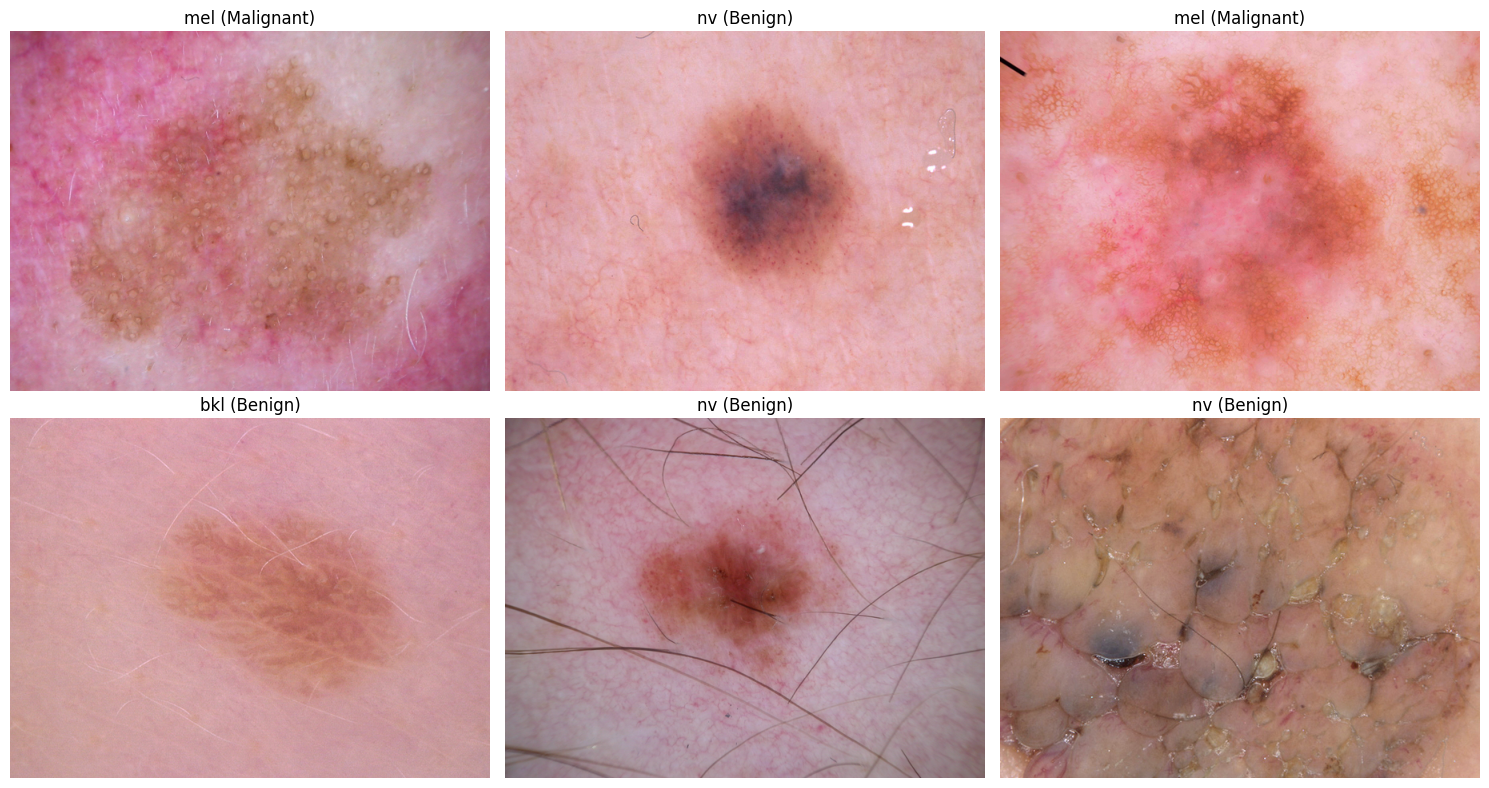

In [ ]:
sample = df.sample(6, random_state=42)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 3, i + 1)

    img = Image.open(row['path'])
    plt.imshow(img)

    plt.title(f"{row['dx']} ({'Malignant' if row['target']==1 else 'Benign'})")
    plt.axis('off')

plt.tight_layout()
plt.show()

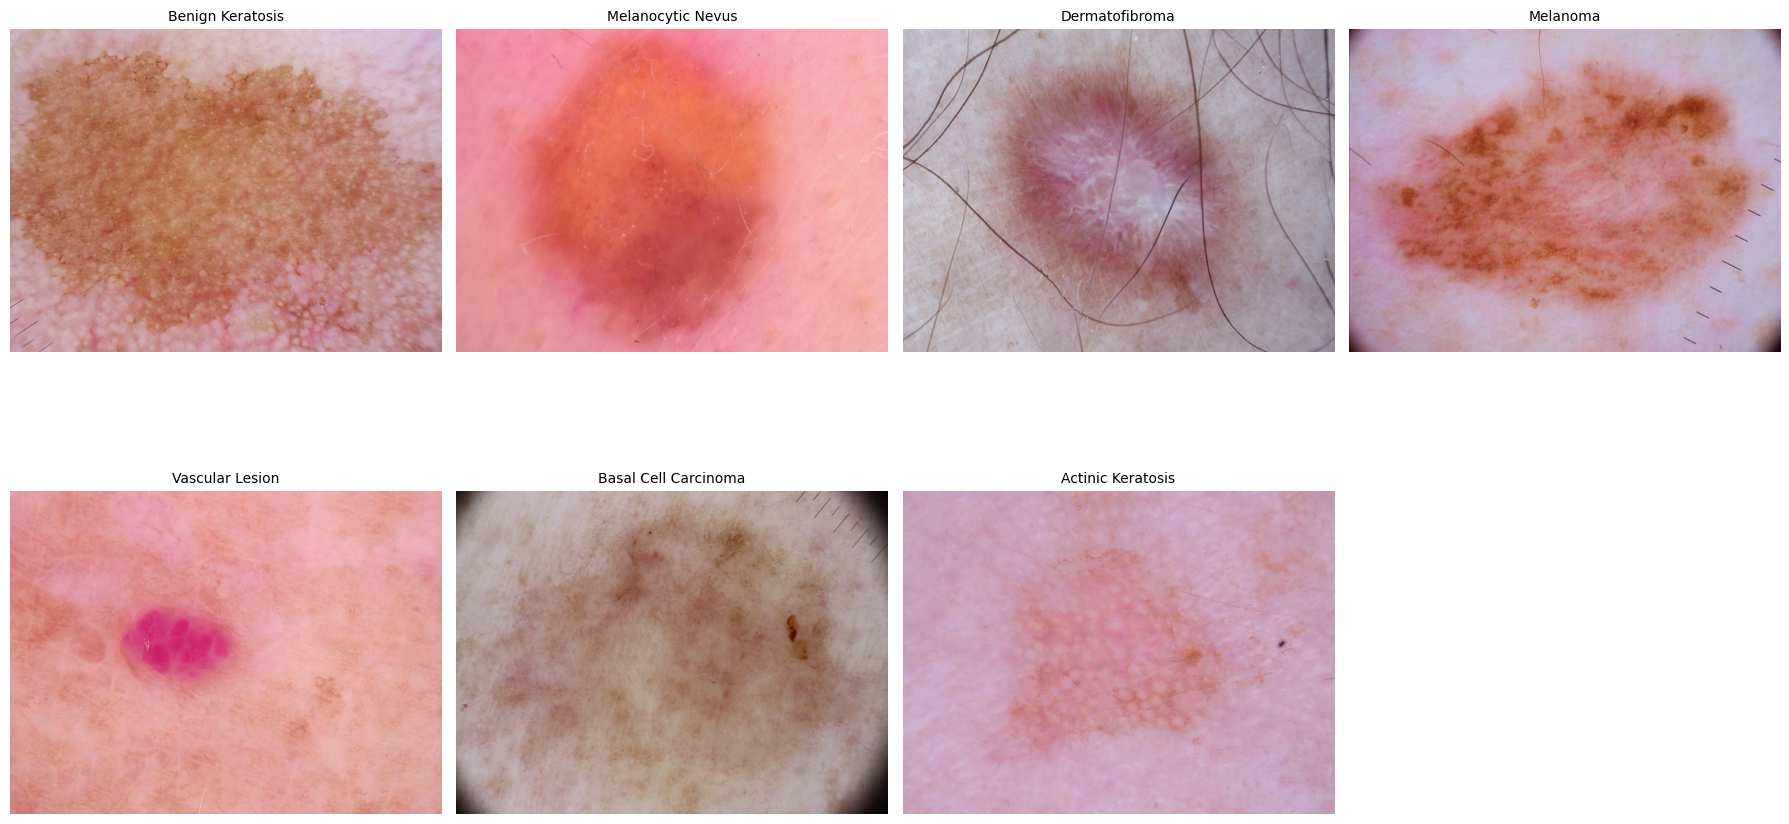

In [ ]:
classes = df['dx'].unique()
labels = {
    'akiec': 'Actinic Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevus',
    'vasc': 'Vascular Lesion'
}

plt.figure(figsize=(18, 10))

for i, lesion in enumerate(classes):
    row = df[df['dx'] == lesion].sample(1, random_state=42).iloc[0]

    plt.subplot(2, 4, i + 1)

    img = Image.open(row['path'])
    plt.imshow(img)

    plt.title(labels[lesion], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
(df['target'].value_counts(normalize=True)*100)

,proportion
target,
0,80.489266
1,19.510734


In [ ]:
#dataset is imbalanced. must be addressed else model becomes biased

In [ ]:
df.isnull().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0
target,0
Age Group,0
path,0


In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,target,Age Group,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80,1,scalp,0,71-80,/content/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80,1,scalp,0,71-80,/content/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80,1,scalp,0,71-80,/content/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80,1,scalp,0,71-80,/content/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75,1,ear,0,71-80,/content/HAM10000_images_part_2/ISIC_0031633.jpg


In [ ]:
df[['image_id', 'path']].head()

,image_id,path
0,ISIC_0027419,/content/HAM10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,/content/HAM10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,/content/HAM10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,/content/HAM10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,/content/HAM10000_images_part_2/ISIC_0031633.jpg


In [ ]:
!pip install lightning-utilities
!pip install torchmetrics --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.9 MB/s eta 0:00:00


DATA PREPROCESSING

In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import v2
from torchvision.transforms.functional import to_pil_image
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score, AUROC

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
from torchvision import transforms

train_transform = v2.Compose([
  v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
  v2.RandomHorizontalFlip(),
  v2.RandomVerticalFlip(),
  v2.RandomRotation(20),
  v2.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]),
])

In [ ]:
eval_transform = v2.Compose([
  v2.Resize((224, 224)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]),
])

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_data, temp_data = train_test_split(df, test_size=0.30, stratify=df['target'], random_state=42)

# Second split: split the remaining 30% into 15% validation and 15% test
val_data, test_data = train_test_split(temp_data, test_size=0.50, stratify=temp_data['target'], random_state=42)

In [ ]:
from torch.utils.data import Dataset

class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['target']

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label, image_path

In [ ]:
train_dataset = SkinLesionDataset(train_data, transform=train_transform)
val_dataset = SkinLesionDataset(val_data, transform=eval_transform)
test_dataset = SkinLesionDataset(test_data, transform=eval_transform)

In [ ]:
image, label, image_path = train_dataset[0]
print(image.shape)
print(label)

torch.Size([3, 224, 224])
tensor(0)


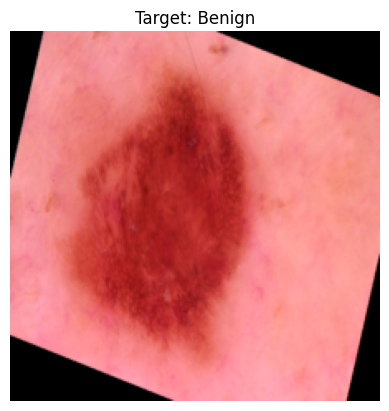

In [ ]:
image, label, image_path = train_dataset[0]
image = image.permute(1, 2, 0)

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

image = image * std + mean
image = image.clamp(0, 1)

plt.imshow(image)
plt.title(f"Target: {'Malignant' if label.item() == 1 else 'Benign'}")
plt.axis("off")
plt.show()

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
images, labels, image_paths = next(iter(train_dataloader))

In [ ]:
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


In [ ]:
print(labels)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
print(images.dtype)
print(labels.dtype)

torch.float32
torch.int64


Model

In [ ]:
class SkinLesionCNN(nn.Module):
    def __init__(self):
        super(SkinLesionCNN, self).__init__()

        self.conv = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size = 3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size = 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size = 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size = 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.AdaptiveAvgPool2d(1),
        )

        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [ ]:
class_counts = torch.tensor([5642, 1368], dtype=torch.float)
class_weights = class_counts.sum() / (2 * class_counts)
class_weights = class_weights.to(device)
print(class_weights)

tensor([0.6212, 2.5621], device='cuda:0')


In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, path="best_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path

        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

            # Save the best model
            torch.save(model.state_dict(), self.path)

        else:
            self.counter += 1

            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    losses = MeanMetric().to(device)
    acc = Accuracy(task='binary').to(device)
    model.train()

    for images, labels, _ in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        prob = torch.softmax(output, dim=1)
        preds = output.argmax(dim=1)
        losses.update(loss, images.size(0))
        acc.update(preds, labels)

    return losses.compute().item(), acc.compute().item()

In [ ]:
def validation_one_epoch(model, dataloader, criterion, device):
    losses = MeanMetric().to(device)
    acc = Accuracy(task='binary').to(device)
    model.eval()

    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            loss = criterion(output, labels)
            prob = torch.softmax(output, dim=1)
            preds = output.argmax(dim=1)
            losses.update(loss, images.size(0))
            acc.update(preds, labels)

    return losses.compute().item(), acc.compute().item()

In [ ]:
def test_model(model, dataloader, device):
    test_acc = Accuracy(task='binary').to(device)
    test_confusion_matrix=ConfusionMatrix(task="binary").to(device)
    test_precision = Precision(task="binary").to(device)
    test_recall = Recall(task="binary").to(device)
    test_f1_score = F1Score(task="binary").to(device)
    test_auroc = AUROC(task="binary").to(device)
    model.eval()

    with torch.no_grad():
      for images, labels, _ in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        prob = torch.softmax(output, dim=1)[:,1]
        preds = output.argmax(dim=1)

        test_confusion_matrix.update(preds, labels)
        test_acc.update(preds, labels)
        test_precision.update(preds, labels)
        test_recall.update(preds, labels)
        test_f1_score.update(preds, labels)
        test_auroc.update(prob, labels)

      print("Confusion Matrix:\n", test_confusion_matrix.compute())
      print("Accuracy:", test_acc.compute().item())
      print("Precision:", test_precision.compute().item())
      print("Recall:", test_recall.compute().item())
      print("F1 Score:", test_f1_score.compute().item())
      print("AUROC:", test_auroc.compute().item())

      return test_confusion_matrix.compute(), test_acc.compute().item(), test_precision.compute().item(), test_recall.compute().item(), test_f1_score.compute().item(), test_auroc.compute().item()

In [ ]:
cnn_model = SkinLesionCNN().to(device)
cnn_optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=0.0001)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
cnn_history = pd.DataFrame()
epochs = 20
early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path="best_cnn_model.pth"
)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(cnn_model, train_dataloader, cnn_optimizer, cnn_criterion, device)
    val_loss, val_acc = validation_one_epoch(cnn_model, val_dataloader, cnn_criterion, device)

    early_stopping(val_loss, cnn_model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    statistics = pd.DataFrame({
        "epoch":[epoch + 1],
        "train_loss":[train_loss],
        "train_acc":[train_acc],
        "val_loss":[val_loss],
        "val_acc":[val_acc]
    })

    cnn_history = pd.concat([cnn_history, statistics], ignore_index=True)
    print(statistics.to_dict(orient='records')[0])

100%|██████████| 24/24 [00:21<00:00,  1.14it/s]


{'epoch': 1, 'train_loss': 0.5764055252075195, 'train_acc': 0.6072753071784973, 'val_loss': 0.5176237225532532, 'val_acc': 0.625832200050354}


100%|██████████| 24/24 [00:17<00:00,  1.40it/s]


{'epoch': 2, 'train_loss': 0.5201696157455444, 'train_acc': 0.6457917094230652, 'val_loss': 0.49184003472328186, 'val_acc': 0.6797603368759155}


100%|██████████| 24/24 [00:17<00:00,  1.39it/s]


...

EarlyStopping Counter: 3/5
{'epoch': 17, 'train_loss': 0.4377230405807495, 'train_acc': 0.7457917332649231, 'val_loss': 0.44835686683654785, 'val_acc': 0.7802929282188416}


100%|██████████| 24/24 [00:17<00:00,  1.41it/s]


EarlyStopping Counter: 4/5
{'epoch': 18, 'train_loss': 0.44321003556251526, 'train_acc': 0.7393723130226135, 'val_loss': 0.4392983317375183, 'val_acc': 0.7656458020210266}


100%|██████████| 24/24 [00:17<00:00,  1.40it/s]

EarlyStopping Counter: 5/5
Early stopping


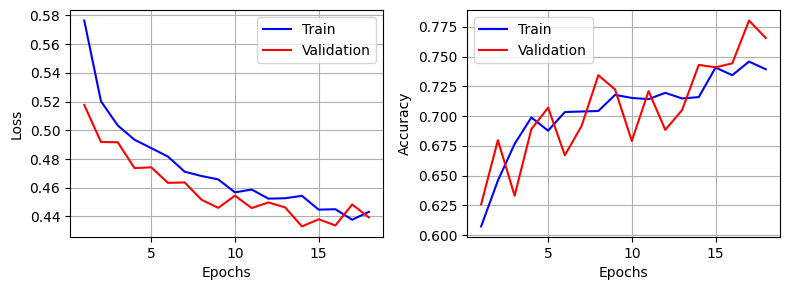

In [ ]:
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)
plt.plot(cnn_history["epoch"], cnn_history["train_loss"], label="Train", color="blue")
plt.plot(cnn_history["epoch"], cnn_history["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)
plt.plot(cnn_history["epoch"], cnn_history["train_acc"], label="Train", color="blue")
plt.plot(cnn_history["epoch"], cnn_history["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
cm_cnn, acc_cnn, prec_cnn, rec_cnn, f1_cnn, auc_cnn = test_model(cnn_model, test_dataloader, device)

Confusion Matrix:
 tensor([[976, 234],
        [ 76, 217]], device='cuda:0')
Accuracy: 0.7937458157539368
Precision: 0.4811529815196991
Recall: 0.7406143546104431
F1 Score: 0.5833333134651184
AUROC: 0.8664175271987915


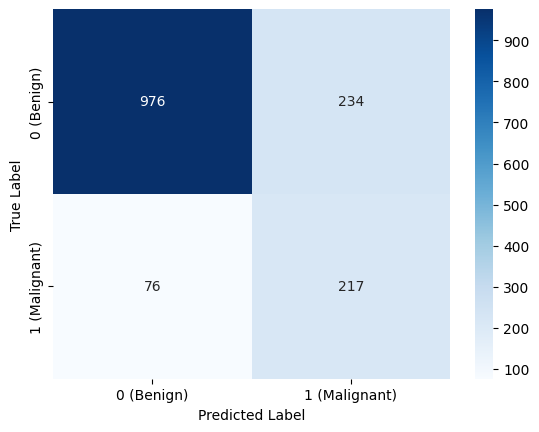

In [ ]:
classes = ['0 (Benign)', '1 (Malignant)']
sns.heatmap(cm_cnn.cpu(), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from torchvision.models import ResNet18_Weights, resnet18

resnet_model = resnet18(weights = ResNet18_Weights.DEFAULT)
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


In [ ]:
resnet_model = resnet_model.to(device)
resnet_optimizer = torch.optim.AdamW(resnet_model.parameters(), lr=0.0001)
resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
resnet_history = pd.DataFrame()
epochs = 20
early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path="best_resnet_model.pth"
)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(resnet_model, train_dataloader, resnet_optimizer, resnet_criterion, device)
    val_loss, val_acc = validation_one_epoch(resnet_model, val_dataloader, resnet_criterion, device)

    early_stopping(val_loss, resnet_model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    statistics = pd.DataFrame({
        "epoch":[epoch + 1],
        "train_loss":[train_loss],
        "train_acc":[train_acc],
        "val_loss":[val_loss],
        "val_acc":[val_acc]
    })
    resnet_history = pd.concat([resnet_history, statistics], ignore_index=True)
    print(statistics.to_dict(orient='records')[0])

100%|██████████| 24/24 [00:17<00:00,  1.36it/s]


{'epoch': 1, 'train_loss': 0.4301638603210449, 'train_acc': 0.7786020040512085, 'val_loss': 0.3826727867126465, 'val_acc': 0.8375499248504639}


100%|██████████| 24/24 [00:17<00:00,  1.37it/s]


{'epoch': 2, 'train_loss': 0.3556461036205292, 'train_acc': 0.8203994035720825, 'val_loss': 0.37764185667037964, 'val_acc': 0.812916100025177}


100%|██████████| 24/24 [00:17<00:00,  1.38it/s]


...

EarlyStopping Counter: 3/5
{'epoch': 10, 'train_loss': 0.16425342857837677, 'train_acc': 0.9261055588722229, 'val_loss': 0.4079975485801697, 'val_acc': 0.8342210650444031}


100%|██████████| 24/24 [00:18<00:00,  1.31it/s]


EarlyStopping Counter: 4/5
{'epoch': 11, 'train_loss': 0.15625764429569244, 'train_acc': 0.9332382082939148, 'val_loss': 0.41289180517196655, 'val_acc': 0.9001331329345703}


100%|██████████| 24/24 [00:18<00:00,  1.33it/s]

EarlyStopping Counter: 5/5
Early stopping


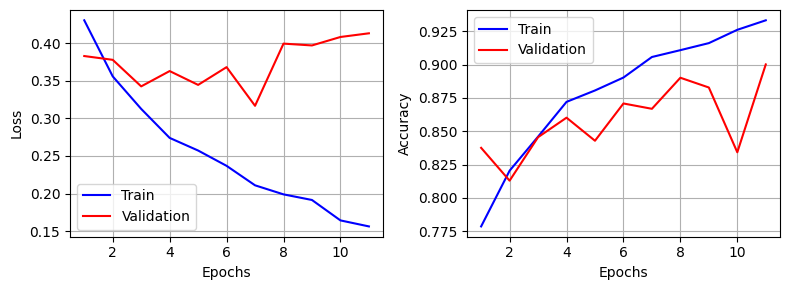

In [ ]:
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)
plt.plot(resnet_history["epoch"], resnet_history["train_loss"], label="Train", color="blue")
plt.plot(resnet_history["epoch"], resnet_history["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)
plt.plot(resnet_history["epoch"], resnet_history["train_acc"], label="Train", color="blue")
plt.plot(resnet_history["epoch"], resnet_history["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
cm_resnet, acc_resnet, prec_resnet, rec_resnet, f1_resnet, auc_resnet = test_model(resnet_model, test_dataloader, device)

Confusion Matrix:
 tensor([[1086,  124],
        [  66,  227]], device='cuda:0')
Accuracy: 0.8735861778259277
Precision: 0.6467236280441284
Recall: 0.7747440338134766
F1 Score: 0.7049689292907715
AUROC: 0.933709442615509


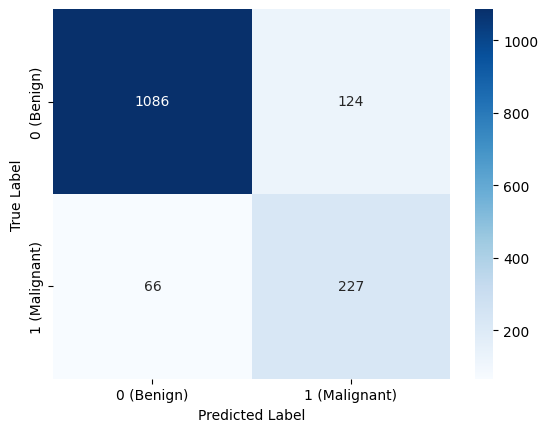

In [ ]:
sns.heatmap(cm_resnet.cpu(), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

eff_model = efficientnet_b0(weights = EfficientNet_B0_Weights.DEFAULT)
num_ftrs = eff_model.classifier[1].in_features
eff_model.classifier[1] = nn.Linear(num_ftrs, 2)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.8MB/s]


In [ ]:
eff_model = eff_model.to(device)
eff_optimizer = torch.optim.AdamW(eff_model.parameters(), lr=0.0001)
eff_criterion = nn.CrossEntropyLoss(weight=class_weights)

In [92]:
eff_history = pd.DataFrame()
epochs = 20
early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path="best_eff_model.pth"
)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(eff_model, train_dataloader, eff_optimizer, eff_criterion, device)
    val_loss, val_acc = validation_one_epoch(eff_model, val_dataloader, eff_criterion, device)

    early_stopping(val_loss, eff_model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    statistics = pd.DataFrame({
        "epoch":[epoch + 1],
        "train_loss":[train_loss],
        "train_acc":[train_acc],
        "val_loss":[val_loss],
        "val_acc":[val_acc]
    })
    eff_history = pd.concat([eff_history, statistics], ignore_index=True)
    print(statistics.to_dict(orient='records')[0])

100%|██████████| 24/24 [00:19<00:00,  1.26it/s]


{'epoch': 1, 'train_loss': 0.4736365079879761, 'train_acc': 0.7159771919250488, 'val_loss': 0.3888169527053833, 'val_acc': 0.7769640684127808}


100%|██████████| 24/24 [00:17<00:00,  1.34it/s]


{'epoch': 2, 'train_loss': 0.35417187213897705, 'train_acc': 0.8206847310066223, 'val_loss': 0.36546680331230164, 'val_acc': 0.8195738792419434}


100%|██████████| 24/24 [00:17<00:00,  1.34it/s]


...

EarlyStopping Counter: 3/5
{'epoch': 8, 'train_loss': 0.1638890951871872, 'train_acc': 0.9276747703552246, 'val_loss': 0.42614129185676575, 'val_acc': 0.8968042731285095}


100%|██████████| 24/24 [00:17<00:00,  1.35it/s]


EarlyStopping Counter: 4/5
{'epoch': 9, 'train_loss': 0.15257102251052856, 'train_acc': 0.9340941309928894, 'val_loss': 0.42922160029411316, 'val_acc': 0.8974700570106506}


100%|██████████| 24/24 [00:18<00:00,  1.31it/s]

EarlyStopping Counter: 5/5
Early stopping


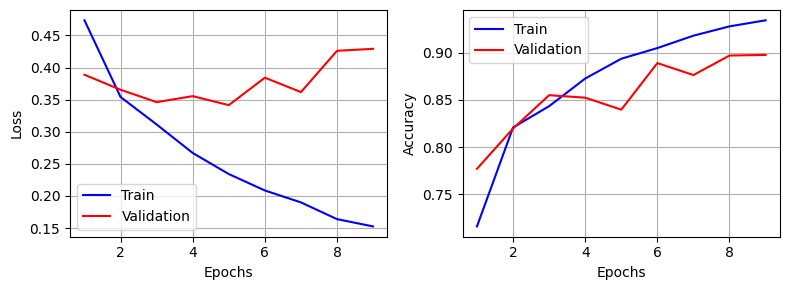

In [93]:
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)
plt.plot(eff_history["epoch"], eff_history["train_loss"], label="Train", color="blue")
plt.plot(eff_history["epoch"], eff_history["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)
plt.plot(eff_history["epoch"], eff_history["train_acc"], label="Train", color="blue")
plt.plot(eff_history["epoch"], eff_history["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [94]:
cm_eff, acc_eff, prec_eff, rec_eff, f1_eff, auc_eff = test_model(eff_model, test_dataloader, device)

Confusion Matrix:
 tensor([[1086,  124],
        [  49,  244]], device='cuda:0')
Accuracy: 0.8848968744277954
Precision: 0.6630434989929199
Recall: 0.8327645063400269
F1 Score: 0.7382753491401672
AUROC: 0.9447973370552063


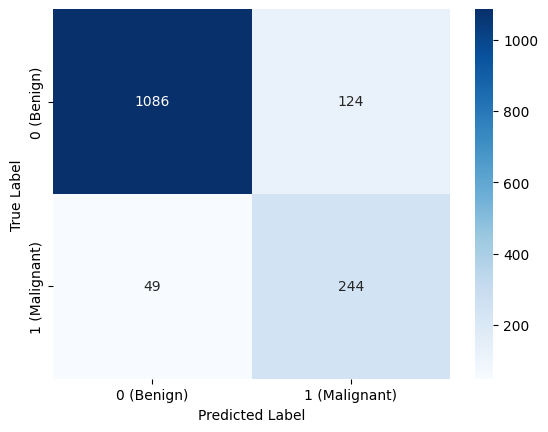

In [95]:
sns.heatmap(cm_eff.cpu(), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [96]:
class_weight_tuned = torch.tensor([0.62, 2.56]).to(device)

In [97]:
tuned_eff_model = efficientnet_b0(weights = EfficientNet_B0_Weights.DEFAULT)
num_ftrs = tuned_eff_model.classifier[1].in_features
tuned_eff_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
     nn.Linear(num_ftrs, 2)
)

In [98]:
tuned_eff_model = tuned_eff_model.to(device)
tuned_eff_optimizer = torch.optim.AdamW(tuned_eff_model.parameters(), lr=0.0002, weight_decay=0.0001)
tuned_eff_criterion = nn.CrossEntropyLoss(weight=class_weights_tuned)

NameError: name 'class_weights_tuned' is not defined

In [ ]:
eff_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tuned_eff_optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

In [ ]:
tuned_eff_history = pd.DataFrame()
epochs = 30
early_stopping = EarlyStopping(
    patience=10,
    min_delta=0.001,
    path="best_tuned_eff_model.pth"
)
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(tuned_eff_model, train_dataloader, tuned_eff_optimizer, tuned_eff_criterion, device)
    val_loss, val_acc = validation_one_epoch(tuned_eff_model, val_dataloader, tuned_eff_criterion, device)

    eff_scheduler.step(val_loss)

    early_stopping(val_loss, tuned_eff_model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    statistics = pd.DataFrame({
        "epoch":[epoch + 1],
        "train_loss":[train_loss],
        "train_acc":[train_acc],
        "val_loss":[val_loss],
        "val_acc":[val_acc]
    })
    tuned_eff_history = pd.concat([tuned_eff_history, statistics], ignore_index=True)
    print(statistics.to_dict(orient='records')[0])

In [ ]:
plt.figure(figsize=(8, 3))
# Plot Loss Curve (Train + Validation)
plt.subplot(1, 2, 1)
plt.plot(tuned_eff_history["epoch"], tuned_eff_history["train_loss"], label="Train", color="blue")
plt.plot(tuned_eff_history["epoch"], tuned_eff_history["val_loss"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
# Plot Accuracy Curve (Train + Validation)
plt.subplot(1, 2, 2)
plt.plot(tuned_eff_history["epoch"], tuned_eff_history["train_acc"], label="Train", color="blue")
plt.plot(tuned_eff_history["epoch"], tuned_eff_history["val_acc"], label="Validation", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
cm_tuned, acc_tuned, prec_tuned, rec_tuned, f1_tuned, auc_tuned = test_model(tuned_eff_model, test_dataloader, device)

In [ ]:
sns.heatmap(cm_tuned.cpu(), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
!wget -q https://isic-challenge-data.s3.amazonaws.com/2016/ISBI2016_ISIC_Part3_Training_Data.zip
!wget -q https://isic-challenge-data.s3.amazonaws.com/2016/ISBI2016_ISIC_Part3_Training_GroundTruth.csv

!unzip -q ISBI2016_ISIC_Part3_Training_Data.zip -d train_data

In [ ]:
print(os.listdir())

In [ ]:
print(os.listdir("train_data")[:10])

In [ ]:
isic_labels = pd.read_csv("ISBI2016_ISIC_Part3_Training_GroundTruth.csv", header=None, names=["image_id", "diagnosis"])
isic_labels.head()

In [ ]:
isic_labels["target"] = isic_labels["diagnosis"].map({"malignant":1, "benign":0})
isic_labels.head()

In [ ]:
isic_labels['target'].value_counts()

In [ ]:
isic_image_dir = "train_data"
isic_labels['path']=isic_labels["image_id"].apply(
    lambda x: os.path.join(isic_image_dir, x + ".jpg")
)
isic_labels.head()

In [ ]:
isic_labels["path"].apply(os.path.exists).value_counts()

In [ ]:
sample = isic_labels.sample(6, random_state=42)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample.iterrows()):
    plt.subplot(2, 3, i + 1)

    img = Image.open(row['path'])
    plt.imshow(img)

plt.tight_layout()
plt.show()

In [ ]:
eval_transform = v2.Compose([
  v2.Resize((224, 224)),
  v2.ToImage(),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406],
               std=[0.229, 0.224, 0.225]),
])

In [ ]:
class ISICDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['target']

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label, image_path

In [ ]:
isic_dataset = ISICDataset(isic_labels, transform=eval_transform)
isic_dataloader = DataLoader(isic_dataset, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
torch.save(tuned_eff_model.state_dict(), "best_tuned_eff_model.pth")

In [ ]:
best_model = tuned_eff_model.to(device)
best_model.load_state_dict(torch.load("best_tuned_eff_model.pth"))
best_model.eval()

In [ ]:
def evaluate_isic(model, dataloader, device):
    test_acc = Accuracy(task='binary').to(device)
    test_confusion_matrix=ConfusionMatrix(task="binary").to(device)
    test_precision = Precision(task="binary").to(device)
    test_recall = Recall(task="binary").to(device)
    test_f1_score = F1Score(task="binary").to(device)
    test_auroc = AUROC(task="binary").to(device)
    model.eval()

    with torch.no_grad():
      for images, labels, _ in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        prob = torch.softmax(output, dim=1)[:,1]
        preds = output.argmax(dim=1)

        test_confusion_matrix.update(preds, labels)
        test_acc.update(preds, labels)
        test_precision.update(preds, labels)
        test_recall.update(preds, labels)
        test_f1_score.update(preds, labels)
        test_auroc.update(prob, labels)

      print("Confusion Matrix:\n", test_confusion_matrix.compute())
      print("Accuracy:", test_acc.compute().item())
      print("Precision:", test_precision.compute().item())
      print("Recall:", test_recall.compute().item())
      print("F1 Score:", test_f1_score.compute().item())
      print("AUROC:", test_auroc.compute().item())

      return test_confusion_matrix.compute(), test_acc.compute().item(), test_precision.compute().item(), test_recall.compute().item(), test_f1_score.compute().item(), test_auroc.compute().item()

In [ ]:
cm_isic, acc_isic, prec_isic, rec_isic, f1_isic, auc_isic = evaluate_isic(best_model, isic_dataloader, device)

In [ ]:
sns.heatmap(cm_isic.cpu(), annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()